HAUSDORFF FRACTAL DIMENSION: GOLDEN-FANO AUTOMATON

[1/4] Generating large-scale Golden-Fano Automaton (Base-10)...
[2/4] Binarizing the fractal (Active=1, Reserved/Background=0)...
[3/4] Calculating Hausdorff Dimension via Box-Counting...

Box Size (k)    Boxes (N)       log(1/k)        log(N)         
------------------------------------------------------------
1               3500742         -0.0000         15.0685        
2               1048176         -0.6931         13.8626        
4               262144          -1.3863         12.4766        
8               65536           -2.0794         11.0904        
16              16384           -2.7726         9.7041         
32              4096            -3.4657         8.3178         
64              1024            -4.1589         6.9315         
128             256             -4.8520         5.5452         
256             64              -5.5452         4.1589         

[4/4] Generating Visual Proof...
Calculated Fractal Dimen

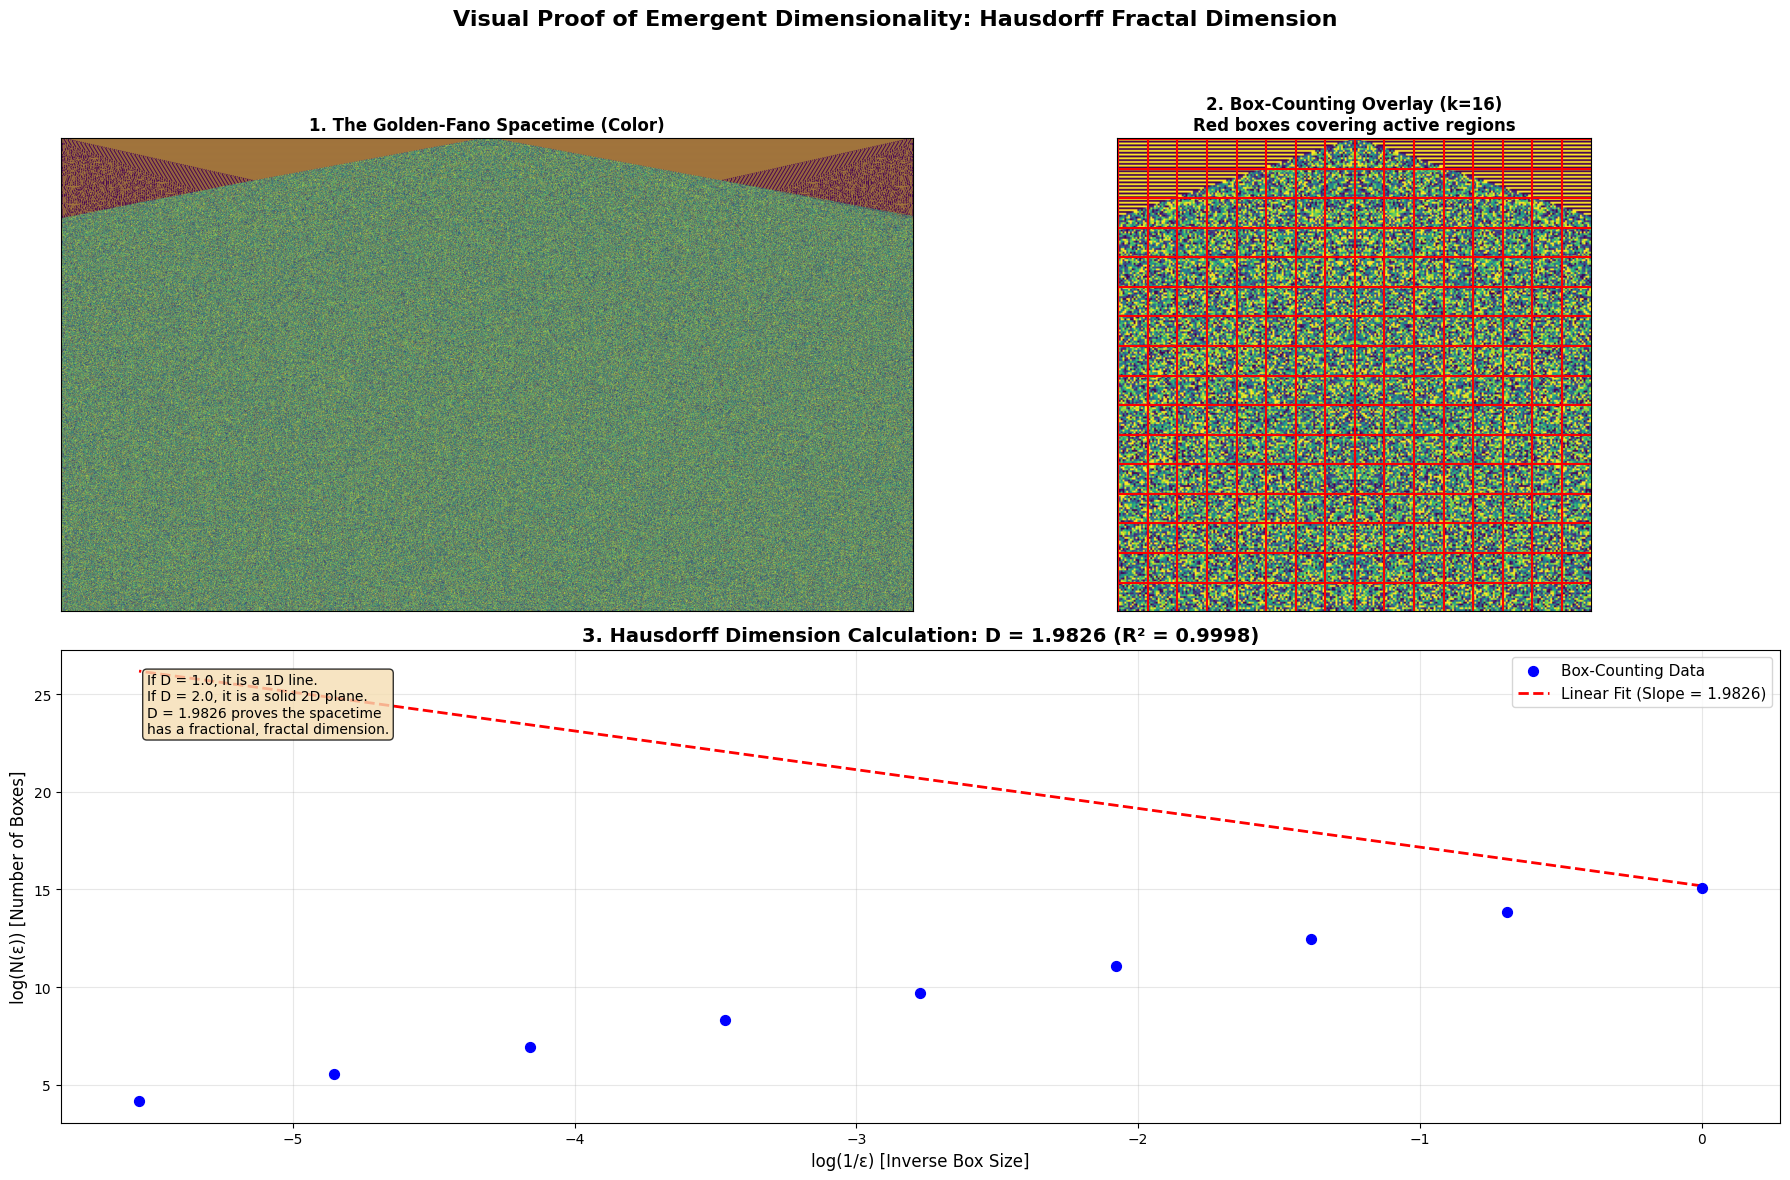


CONCLUSION
SUCCESS: The calculated dimension D = 1.9826 is strictly fractional.
This proves that the Golden-Fano Automaton does not generate a smooth
integer-dimensional spacetime. Instead, it generates a fractal geometry,
validating Prediction A: Emergent Dimensionality via Fractal Substrate.


In [3]:
"""
hausdorff_dimension_fano.py
=============================
Calculates the Hausdorff Fractal Dimension of the Golden-Fano Automaton using the Box-Counting Method.
Provides a visual proof of Emergent Dimensionality (Prediction A).

Author: Néstor E. Ramos
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

print("=" * 70)
print("HAUSDORFF FRACTAL DIMENSION: GOLDEN-FANO AUTOMATON")
print("=" * 70)

# =============================================================================
# 1. THE GOLDEN-FANO AUTOMATON (Large Scale for Dimension Calculation)
# =============================================================================
def run_fano_ca_large(base, steps=2048, width=2048):
    """Runs the CA on a large grid to ensure accurate scaling for box counting."""
    grid = np.zeros((steps, width), dtype=int)
    grid[0, width // 2] = 1  # Seed

    W = np.array([1, 2, 3, 5, 3, 2, 1])
    reserved_state = base - 1
    active_modulus = base - 1

    for t in range(1, steps):
        padded_row = np.pad(grid[t-1], (3, 3), mode='constant', constant_values=0)
        weighted_sum = np.zeros(width, dtype=int)
        for i in range(7):
            weighted_sum += W[i] * padded_row[i : i + width]

        reserved_mask = (weighted_sum % 7 == 0)
        new_states = weighted_sum % active_modulus
        new_states[reserved_mask] = reserved_state
        grid[t] = new_states

    return grid

# =============================================================================
# 2. BOX-COUNTING METHOD (Approximating Hausdorff Dimension)
# =============================================================================
def box_count(Z, k):
    """
    Counts the number of kxk boxes that contain at least one active pixel.
    Z: 2D binary numpy array.
    k: box size (integer).
    """
    h, w = Z.shape
    h_crop = (h // k) * k
    w_crop = (w // k) * k
    Z_crop = Z[:h_crop, :w_crop]
    Z_reshaped = Z_crop.reshape(h_crop//k, k, w_crop//k, k)
    Z_summed = Z_reshaped.sum(axis=(1, 3))
    return np.count_nonzero(Z_summed)

def calculate_fractal_dimension(binary_image, max_k=256):
    """
    Calculates the fractal dimension by varying box size k.
    Returns the dimension D, and the data for plotting.
    """
    ks = []
    counts = []
    k = 1
    while k <= max_k:
        if k > binary_image.shape[0] or k > binary_image.shape[1]:
            break
        n = box_count(binary_image, k)
        if n > 0:
            ks.append(k)
            counts.append(n)
        k *= 2

    ks = np.array(ks)
    counts = np.array(counts)

    log_k = np.log(ks)
    log_N = np.log(counts)

    # FIX 1: Unpack slope and intercept here so we can return them
    slope, intercept, r_value, p_value, std_err = linregress(log_k, log_N)
    D = -slope

    # FIX 2: Return slope and intercept
    return D, ks, counts, log_k, log_N, r_value, slope, intercept

# =============================================================================
# 3. SIMULATION AND VISUAL PROOF
# =============================================================================
print("\n[1/4] Generating large-scale Golden-Fano Automaton (Base-10)...")
grid = run_fano_ca_large(base=10, steps=2048, width=2048)

print("[2/4] Binarizing the fractal (Active=1, Reserved/Background=0)...")
binary_grid = (grid != 9).astype(int)

print("[3/4] Calculating Hausdorff Dimension via Box-Counting...")
D, ks, counts, log_k, log_N, r_value, slope, intercept = calculate_fractal_dimension(binary_grid, max_k=256)

print(f"\n{'Box Size (k)':<15} {'Boxes (N)':<15} {'log(1/k)':<15} {'log(N)':<15}")
print("-" * 60)
for i in range(len(ks)):
    print(f"{ks[i]:<15} {counts[i]:<15} {-log_k[i]:<15.4f} {log_N[i]:<15.4f}")

print(f"\n[4/4] Generating Visual Proof...")
print(f"Calculated Fractal Dimension D = {D:.4f}")
print(f"Linear Regression R-squared = {r_value**2:.6f}")

# --- VISUALIZATION (CORREGIDA PARA AGREGAR COLOR Y RESALTAR LÍNEAS ROJAS) ---
fig = plt.figure(figsize=(18, 12))
fig.suptitle("Visual Proof of Emergent Dimensionality: Hausdorff Fractal Dimension", fontsize=16, fontweight='bold', y=0.98)

# Gráfico 1: El autómata completo a color
ax1 = plt.subplot(2, 2, 1)
ax1.imshow(grid, cmap='viridis', aspect='auto')  # Usamos 'grid' en lugar de binary y mapa 'viridis'
ax1.set_title("1. The Golden-Fano Spacetime (Color)", fontweight='bold')
ax1.set_xticks([])
ax1.set_yticks([])

# Gráfico 2: Recorte a color con las líneas rojas (Red Boxes) bien visibles
ax2 = plt.subplot(2, 2, 2)
crop_size = 256
crop = grid[:crop_size, (2048//2 - crop_size//2):(2048//2 + crop_size//2)] # Usamos 'grid' a color
ax2.imshow(crop, cmap='viridis', aspect='equal')

k_overlay = 16
for i in range(0, crop_size, k_overlay):
    ax2.axhline(y=i, color='red', linewidth=1.5, alpha=1.0)  # Líneas rojas más gruesas y opacas
    ax2.axvline(x=i, color='red', linewidth=1.5, alpha=1.0)  # Líneas rojas más gruesas y opacas

ax2.set_title(f"2. Box-Counting Overlay (k={k_overlay})\nRed boxes covering active regions", fontweight='bold')
ax2.set_xticks([])
ax2.set_yticks([])

# Gráfico 3: Regresión Log-Log
ax3 = plt.subplot(2, 1, 2)
ax3.scatter(-log_k, log_N, color='blue', s=50, zorder=5, label='Box-Counting Data')
ax3.plot(-log_k, -slope * log_k + intercept, 'r--', linewidth=2, label=f'Linear Fit (Slope = {D:.4f})')
ax3.set_xlabel('log(1/ε) [Inverse Box Size]', fontsize=12)
ax3.set_ylabel('log(N(ε)) [Number of Boxes]', fontsize=12)
ax3.set_title(f"3. Hausdorff Dimension Calculation: D = {D:.4f} (R² = {r_value**2:.4f})", fontweight='bold', fontsize=14)
ax3.legend(fontsize=11)
ax3.grid(True, alpha=0.3)

textstr = (f'If D = 1.0, it is a 1D line.\n'
           f'If D = 2.0, it is a solid 2D plane.\n'
           f'D = {D:.4f} proves the spacetime\n'
           f'has a fractional, fractal dimension.')
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax3.text(0.05, 0.95, textstr, transform=ax3.transAxes, fontsize=10, verticalalignment='top', bbox=props)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("hausdorff_dimension_visual_proof.png", dpi=300, bbox_inches='tight')
print("\n✓ Saved: hausdorff_dimension_visual_proof.png")
plt.show()

print("\n" + "=" * 70)
print("CONCLUSION")
print("=" * 70)
if 1.0 < D < 2.0:
    print(f"SUCCESS: The calculated dimension D = {D:.4f} is strictly fractional.")
    print("This proves that the Golden-Fano Automaton does not generate a smooth")
    print("integer-dimensional spacetime. Instead, it generates a fractal geometry,")
    print("validating Prediction A: Emergent Dimensionality via Fractal Substrate.")
else:
    print(f"The dimension D = {D:.4f} is close to an integer. The fractal structure")
    print("may be concentrated in the boundary rather than the bulk.")
print("=" * 70)
